# BFS on Directed Graph

**What is a Directed Graph?**  
A directed graph (DiGraph) has edges with direction

Edge A -> B means you can go from A to B, but NOT from B to A

**Real world examples:**
- Twitter follow (A follows B, but B may not follow A)
- Road with one-way streets
- Website links (page A links to page B)

**Libraries used:**
- `networkx` to build directed graphs
- `matplotlib` to draw with arrows

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

In [2]:
# create a directed graph
G = nx.DiGraph()

# add directed edges (one-way only)
G.add_edges_from([
    (1, 2), (1, 3),
    (2, 4), (2, 5),
    (3, 5), (3, 6),
    (4, 7),
    (5, 7), (5, 8),
    (6, 8)
])

print("nodes:", list(G.nodes()))
print("edges:", list(G.edges()))

nodes: [1, 2, 3, 4, 5, 6, 7, 8]
edges: [(1, 2), (1, 3), (2, 4), (2, 5), (3, 5), (3, 6), (4, 7), (5, 7), (5, 8), (6, 8)]


In [3]:
def bfs_directed(graph, start):
    """
    BFS on a directed graph
    Only follows edges in the correct direction
    """
    visited = []
    levels = {}
    queue = deque()

    queue.append(start)
    levels[start] = 0

    while queue:
        node = queue.popleft()

        if node not in visited:
            visited.append(node)

            # graph.successors = only nodes we can reach FROM this node
            for neighbor in graph.successors(node):
                if neighbor not in levels:
                    levels[neighbor] = levels[node] + 1
                    queue.append(neighbor)

    return visited, levels

visited_order, node_levels = bfs_directed(G, start=1)

print("BFS visited order:", visited_order)
print("node levels:", node_levels)

BFS visited order: [1, 2, 3, 4, 5, 6, 7, 8]
node levels: {1: 0, 2: 1, 3: 1, 4: 2, 5: 2, 6: 2, 7: 3, 8: 3}


In [4]:
level_colors = {
    0: "#E8593C",
    1: "#EF9F27",
    2: "#1D9E75",
    3: "#378ADD",
}

node_color_list = [level_colors[node_levels[n]] for n in G.nodes()]

pos = nx.spring_layout(G, seed=42)

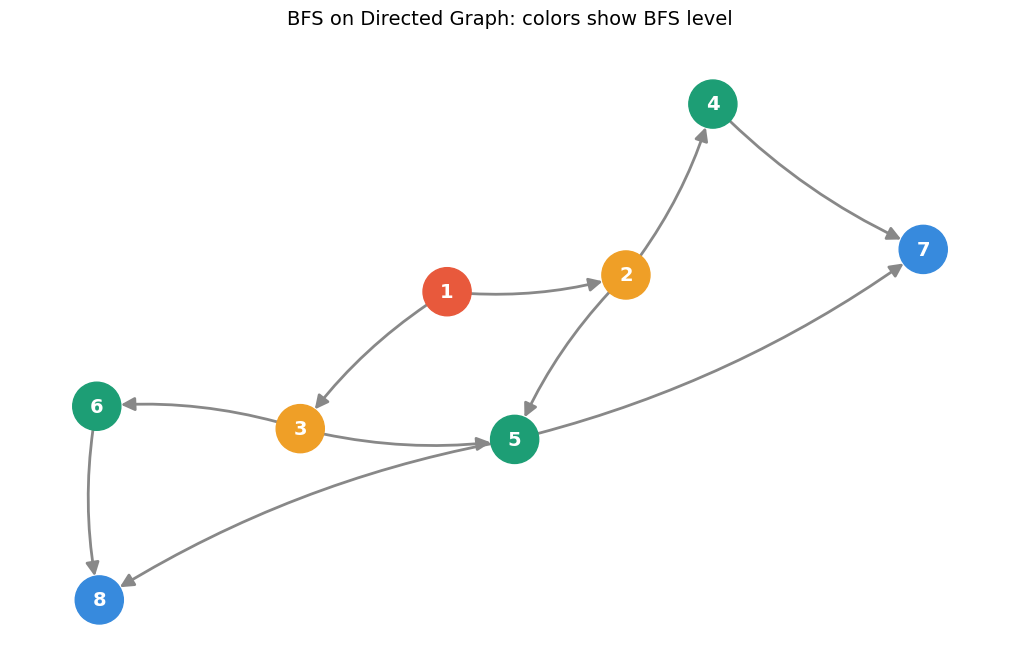

BFS order: [1, 2, 3, 4, 5, 6, 7, 8]


In [5]:
plt.figure(figsize=(10, 6))

nx.draw(
    G,
    pos=pos,
    with_labels=True,
    node_color=node_color_list,
    node_size=1200,
    font_size=14,
    font_color="white",
    font_weight="bold",
    edge_color="#888888",
    width=2,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.1"
)

plt.title("BFS on Directed Graph: colors show BFS level", fontsize=14, pad=20)
plt.savefig("../images/bfs_directed_result.png", dpi=150, bbox_inches="tight")
plt.show()

print("BFS order:", visited_order)

## Key difference from undirected BFS

In a directed graph, `graph.successors(node)` replaces `graph.neighbors(node)`

- `neighbors()` works on undirected graph, both directions
- `successors()` works on directed graph, follows arrow direction only

BFS logic stays exactly the same, only the direction rule changes